# Strategy Design


In [1]:
import numpy as np

from hftbacktest import (
    BacktestAsset,
    HashMapMarketDepthBacktest,
    ROIVectorMarketDepthBacktest,
    Recorder
)
import matplotlib.pyplot as plt
from hftbacktest.stats import LinearAssetRecord

Save the backtest module into `lib/pmm.py`


In [2]:
import lib.pmm_pure as pmm_pure

In [3]:
# %%time
xrpusdt_20250718 = np.load('data/output/xrpusdt_20250718.npz')['data']


roi_lb = 1    # ROI lower bound 100 ticks, price lower limit for order book depth calculation
roi_ub = 5    # ROI upper bound 200 ticks, price upper limit for order book depth calculation

asset = (
    BacktestAsset()
    .data([
        xrpusdt_20250718
    ])
    .linear_asset(1)
    .no_partial_fill_exchange()
    .constant_latency(10_000_000, 10_000_000)
    .tick_size(0.0001)  # Minimum price precision (0.01 USDT)
    .lot_size(0.1)  # Minimum trading amount (0.001 ETH)
    .trading_value_fee_model(-0.00003, 0.0007)  # Binance
    .power_prob_queue_model3(1.0)
    .risk_adverse_queue_model()
)


# hbt = ROIVectorMarketDepthBacktest([asset])
hbt = HashMapMarketDepthBacktest([asset])
recorder = Recorder(1, 5_000_000)

_ = pmm_pure.pure_pmm(
    hbt,
    recorder.recorder,
    half_spread=35,
    skew=1,
    interval=1_000_000_000,
    order_qty_dollar=10,
    max_position_dollar=1000,
    grid_num=10,
    grid_interval=30
)

_ = hbt.close()

record_path = 'stats/pmm_xrpusdt1.npz'
recorder.to_npz(record_path)

/var/folders/sz/2_qpjlss61bfv6n0cp6xj9qc0000gn/T/ipykernel_49254/2204945090.py:15: DeprecationWarning: constant_latency() is deprecated; use constant_order_latency().
  .constant_latency(10_000_000, 10_000_000)


In [4]:
# data = np.load('stats/pmm_xrpusdt1.npz')['0']
# stats = LinearAssetRecord(data).resample('1s').stats(book_size=100)

# stats = (
#     LinearAssetRecord(data)
#     .resample('1s')
#     .stats()
# )
# stats.summary()

/var/folders/sz/2_qpjlss61bfv6n0cp6xj9qc0000gn/T/ipykernel_49254/856245573.py:178: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/zhoudl0605/miniconda3/envs/rl_pmm/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


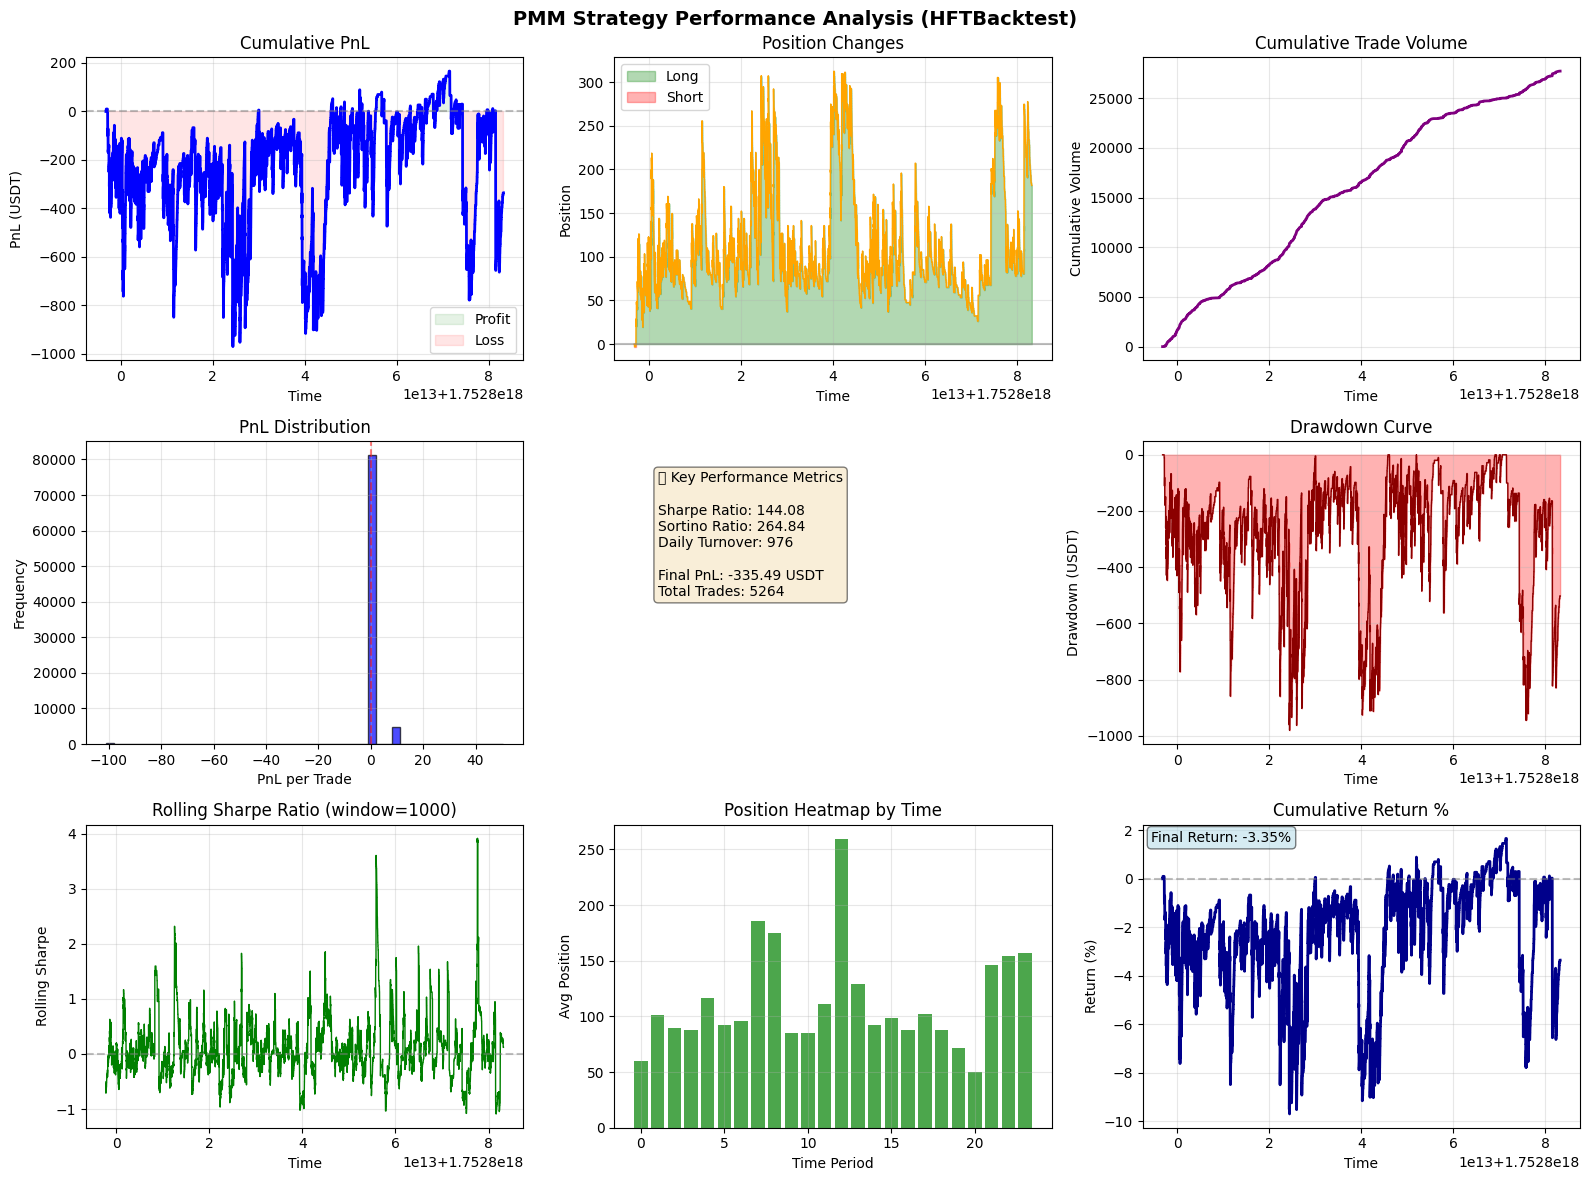


📊 HFTBacktest Statistics Summary:
shape: (1, 11)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ start     ┆ end       ┆ SR        ┆ Sortino   ┆ … ┆ DailyTurn ┆ ReturnOve ┆ ReturnOve ┆ MaxPosit │
│ ---       ┆ ---       ┆ ---       ┆ ---       ┆   ┆ over      ┆ rMDD      ┆ rTrade    ┆ ionValue │
│ datetime[ ┆ datetime[ ┆ f64       ┆ f64       ┆   ┆ ---       ┆ ---       ┆ ---       ┆ ---      │
│ μs]       ┆ μs]       ┆           ┆           ┆   ┆ f64       ┆ f64       ┆ f64       ┆ f64      │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ 2025-07-1 ┆ 2025-07-1 ┆ 144.08012 ┆ 264.83940 ┆ … ┆ 975.64804 ┆ 30.665621 ┆ 0.002959  ┆ 1077.144 │
│ 8         ┆ 8         ┆ 3         ┆ 3         ┆   ┆           ┆           ┆           ┆ 97       │
│ 00:00:00  ┆ 23:59:00  ┆           ┆           ┆   ┆           ┆           ┆           ┆          │
└───────────┴───────────┴───────────┴────

In [5]:
def plot_strategy_performance(result_file_or_data):
    """Plot PMM strategy performance analysis charts (based on HFTBacktest statistics)"""
    
    # Check if input is a file path or numpy array
    if isinstance(result_file_or_data, str):
        data = np.load(result_file_or_data)['0']
    else:
        data = result_file_or_data
    
    # Use HFTBacktest statistics functionality
    asset_record = LinearAssetRecord(data)
    stats = asset_record.resample('1m').stats(book_size=100)
    summary = stats.summary()
    
    # Extract data
    timestamps = data['timestamp']
    balance = data['balance']
    position = data['position']
    
    # Create professional charts
    fig = plt.figure(figsize=(16, 12))
    
    # 1. Cumulative PnL curve
    ax1 = plt.subplot(3, 3, 1)
    ax1.plot(timestamps, balance, linewidth=2, color='blue')
    ax1.fill_between(timestamps, 0, balance, where=(balance > 0), 
                     color='green', alpha=0.1, label='Profit')
    ax1.fill_between(timestamps, 0, balance, where=(balance < 0), 
                     color='red', alpha=0.1, label='Loss')
    ax1.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    ax1.set_xlabel('Time')
    ax1.set_ylabel('PnL (USDT)')
    ax1.set_title('Cumulative PnL')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # 2. Position changes
    ax2 = plt.subplot(3, 3, 2)
    ax2.plot(timestamps, position, linewidth=1, color='orange')
    ax2.fill_between(timestamps, 0, position, where=(position > 0),
                     color='green', alpha=0.3, label='Long')
    ax2.fill_between(timestamps, 0, position, where=(position < 0),
                     color='red', alpha=0.3, label='Short')
    ax2.axhline(y=0, color='gray', linestyle='-', alpha=0.5)
    ax2.set_xlabel('Time')
    ax2.set_ylabel('Position')
    ax2.set_title('Position Changes')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # 3. Cumulative trading volume
    ax3 = plt.subplot(3, 3, 3)
    position_changes = np.abs(np.diff(position))
    cumulative_volume = np.cumsum(position_changes)
    ax3.plot(timestamps[1:], cumulative_volume, linewidth=2, color='purple')
    ax3.set_xlabel('Time')
    ax3.set_ylabel('Cumulative Volume')
    ax3.set_title('Cumulative Trade Volume')
    ax3.grid(True, alpha=0.3)
    
    # 4. PnL distribution histogram
    ax4 = plt.subplot(3, 3, 4)
    returns = np.diff(balance)
    if len(returns) > 0:
        ax4.hist(returns, bins=50, alpha=0.7, color='blue', edgecolor='black')
        ax4.axvline(x=0, color='red', linestyle='--', alpha=0.5)
        ax4.set_xlabel('PnL per Trade')
        ax4.set_ylabel('Frequency')
        ax4.set_title('PnL Distribution')
        ax4.grid(True, alpha=0.3)
    
    # 5. Key metrics display
    ax5 = plt.subplot(3, 3, 5)
    ax5.axis('off')
    
    # Extract key metrics from summary
    metrics_text = "📊 Key Performance Metrics\n\n"
    
    if 'SR' in summary.columns:
        metrics_text += f"Sharpe Ratio: {float(summary['SR'][0]):.2f}\n"
    if 'Sortino' in summary.columns:
        metrics_text += f"Sortino Ratio: {float(summary['Sortino'][0]):.2f}\n"
    if 'Ret' in summary.columns:
        metrics_text += f"Total Return: {float(summary['Ret'][0]):.4f}\n"
    if 'MaxDD' in summary.columns:
        metrics_text += f"Max Drawdown: {float(summary['MaxDD'][0]):.4f}\n"
    if 'DailyTurnover' in summary.columns:
        metrics_text += f"Daily Turnover: {float(summary['DailyTurnover'][0]):.0f}\n"
    if 'RetOverMDD' in summary.columns:
        metrics_text += f"Return/MDD: {float(summary['RetOverMDD'][0]):.2f}\n"
    
    metrics_text += f"\nFinal PnL: {balance[-1]:.2f} USDT"
    metrics_text += f"\nTotal Trades: {np.sum(np.diff(position) != 0)}"
    
    ax5.text(0.1, 0.9, metrics_text, transform=ax5.transAxes, 
            fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    # 6. Drawdown curve
    ax6 = plt.subplot(3, 3, 6)
    # Calculate drawdown
    cummax = np.maximum.accumulate(balance)
    drawdown = balance - cummax
    ax6.fill_between(timestamps, 0, drawdown, color='red', alpha=0.3)
    ax6.plot(timestamps, drawdown, linewidth=1, color='darkred')
    ax6.set_xlabel('Time')
    ax6.set_ylabel('Drawdown (USDT)')
    ax6.set_title('Drawdown Curve')
    ax6.grid(True, alpha=0.3)
    
    # 7. Rolling Sharpe Ratio (if sufficient data)
    ax7 = plt.subplot(3, 3, 7)
    window = 1000  # Window of 1000 data points
    if len(returns) > window:
        rolling_sharpe = []
        for i in range(window, len(returns)):
            window_returns = returns[i-window:i]
            if np.std(window_returns) > 0:
                sharpe = np.mean(window_returns) / np.std(window_returns) * np.sqrt(252)
                rolling_sharpe.append(sharpe)
            else:
                rolling_sharpe.append(0)
        ax7.plot(timestamps[window+1:], rolling_sharpe, linewidth=1, color='green')
        ax7.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
        ax7.set_xlabel('Time')
        ax7.set_ylabel('Rolling Sharpe')
        ax7.set_title(f'Rolling Sharpe Ratio (window={window})')
        ax7.grid(True, alpha=0.3)
    
    # 8. Position heatmap
    ax8 = plt.subplot(3, 3, 8)
    # Divide time into hourly segments, calculate average position per hour
    hour_bins = 24
    position_by_hour = []
    timestamps_hours = []
    
    total_time = timestamps[-1] - timestamps[0]
    hour_size = total_time / hour_bins
    
    for i in range(hour_bins):
        start_time = timestamps[0] + i * hour_size
        end_time = start_time + hour_size
        mask = (timestamps >= start_time) & (timestamps < end_time)
        if np.any(mask):
            position_by_hour.append(np.mean(position[mask]))
            timestamps_hours.append(start_time)
    
    if position_by_hour:
        colors_map = ['red' if p < 0 else 'green' for p in position_by_hour]
        ax8.bar(range(len(position_by_hour)), position_by_hour, color=colors_map, alpha=0.7)
        ax8.set_xlabel('Time Period')
        ax8.set_ylabel('Avg Position')
        ax8.set_title('Position Heatmap by Time')
        ax8.grid(True, alpha=0.3)
    
    # 9. Cumulative return curve
    ax9 = plt.subplot(3, 3, 9)
    # Assume initial capital of 10000 USDT
    initial_capital = 10000
    returns_pct = (balance / initial_capital) * 100
    ax9.plot(timestamps, returns_pct, linewidth=2, color='darkblue')
    ax9.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    ax9.set_xlabel('Time')
    ax9.set_ylabel('Return (%)')
    ax9.set_title('Cumulative Return %')
    ax9.grid(True, alpha=0.3)
    
    # Add annotations
    if len(returns_pct) > 0:
        final_return = returns_pct[-1]
        ax9.text(0.02, 0.98, f'Final Return: {final_return:.2f}%',
                transform=ax9.transAxes, fontsize=10,
                verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))
    
    plt.suptitle('PMM Strategy Performance Analysis (HFTBacktest)', 
                fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Print detailed statistics
    print("\n📊 HFTBacktest Statistics Summary:")
    print("="*60)
    print(summary)
    
    # Print additional statistics
    print("\n📈 Additional Performance Metrics:")
    print("-"*60)
    
    if len(returns) > 0:
        positive_returns = returns[returns > 0]
        negative_returns = returns[returns < 0]
        
        print(f"Total Trades: {np.sum(np.diff(position) != 0)}")
        print(f"Winning Trades: {len(positive_returns)}")
        print(f"Losing Trades: {len(negative_returns)}")
        
        if len(positive_returns) > 0 and len(negative_returns) > 0:
            win_rate = len(positive_returns) / len(returns) * 100
            avg_win = np.mean(positive_returns)
            avg_loss = np.mean(negative_returns)
            profit_factor = np.sum(positive_returns) / abs(np.sum(negative_returns))
            
            print(f"Win Rate: {win_rate:.2f}%")
            print(f"Average Win: {avg_win:.4f} USDT")
            print(f"Average Loss: {avg_loss:.4f} USDT")
            print(f"Profit Factor: {profit_factor:.2f}")
    
    print(f"\nMax Position: {np.max(np.abs(position)):.2f}")
    print(f"Average Position: {np.mean(np.abs(position)):.2f}")
    print(f"Final PnL: {balance[-1]:.2f} USDT")
    
    return stats

# Plot strategy performance analysis
stats = plot_strategy_performance(record_path)